# Joint Deepfake Detection — FakeAVCeleb + LAV-DF + FF++

Trains a single 4-class multimodal model across all 3 datasets.

### Key improvements over single-dataset training
- **Domain-balanced sampling** — each dataset contributes equally per batch
- **Audio dropout augmentation** — randomly zeros audio to prevent over-reliance on audio for video-only fakes
- **Cross-dataset validation** — evaluates on each dataset's test split separately
- **Train from scratch** — no bias from FakeAVCeleb-only checkpoint

### Dataset paths
```
FakeAVCeleb : processed_dataset_v7/          (~20k files, classes 0-3)
LAV-DF      : lavdf_ts_processed/train|test  (800/320 files, classes 0-3)
FF++        : ff_processed/train|test        (640/160 files, classes 0-1)
```

### Label scheme
- 0 = Real/Real
- 1 = FakeVideo/RealAudio
- 2 = RealVideo/FakeAudio
- 3 = Fake/Fake


In [2]:
# ── CELL 1: SETUP ─────────────────────────────────────────────────────────
!pip install torch torchvision tqdm scikit-learn -q
print('Setup done.')

Setup done.


In [1]:
# ── CELL 2: IMPORTS ───────────────────────────────────────────────────────
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, ConcatDataset
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.checkpoint import checkpoint
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print('Device:', device)

Mounted at /content/drive
Device: cpu


In [6]:
# ── CELL 3: CONFIG ────────────────────────────────────────────────────────
DRIVE_BASE = '/content/drive/MyDrive/Deepfake'

DATASET_PATHS = {
    'fakeavceleb': {
        'train': os.path.join(DRIVE_BASE, 'processed_dataset_v7'),
        'test' : os.path.join(DRIVE_BASE, 'processed_dataset_v7'),  # uses internal split
    },
    'lavdf': {
        'train': os.path.join(DRIVE_BASE, 'lavdf_ts_processed/train'),
        'test' : os.path.join(DRIVE_BASE, 'lavdf_ts_processed/test'),
    },
    'ffpp': {
        'train': os.path.join(DRIVE_BASE, 'ff_processed/train'),
        'test' : os.path.join(DRIVE_BASE, 'ff_processed/test'),
    },
}

# Training
EPOCHS        = 10
BATCH_SIZE    = 12
LR            = 1e-4
AUDIO_DROP_P  = 0.3   # probability of zeroing audio — forces model to use video

# FakeAVCeleb needs an internal 80/20 split since it has no separate test folder
FAKEAVCELEB_TEST_RATIO = 0.2

# Save paths
CHECKPOINT_PATH = os.path.join(DRIVE_BASE, 'joint_model_checkpoint.pth')
MODEL_PATH      = os.path.join(DRIVE_BASE, 'joint_model.pth')

CLASS_NAMES = {
    0: 'Real/Real',
    1: 'FakeVideo/RealAudio',
    2: 'RealVideo/FakeAudio',
    3: 'Fake/Fake'
}

print('Config ready.')
for name, paths in DATASET_PATHS.items():
    for split, path in paths.items():
        exists = os.path.exists(path)
        n = len([f for f in os.listdir(path) if f.endswith('.npz')]) if exists else 0
        print(f'  {name}/{split}: {n} files  {"✅" if exists else "❌"}')

Config ready.
  fakeavceleb/train: 20559 files  ✅
  fakeavceleb/test: 20559 files  ✅
  lavdf/train: 800 files  ✅
  lavdf/test: 320 files  ✅
  ffpp/train: 640 files  ✅
  ffpp/test: 160 files  ✅


In [10]:
# ── CELL 4: DATASET CLASS + TRAIN/TEST SPLIT ──────────────────────────────
import random, pandas as pd
random.seed(42)
np.random.seed(42)

class DeepfakeDataset(Dataset):
    def __init__(self, root, files, audio_drop_p=0.0):
        self.root         = root
        self.files        = files
        self.audio_drop_p = audio_drop_p

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data   = np.load(os.path.join(self.root, self.files[idx]), mmap_mode='r')
        frames = torch.from_numpy(data['frames'].copy()).permute(0,3,1,2).float() / 255
        audio  = torch.from_numpy(data['audio'].copy()).unsqueeze(1).float()
        label  = torch.tensor(int(data['label'])).long()
        if self.audio_drop_p > 0 and random.random() < self.audio_drop_p:
            audio = torch.zeros_like(audio)
        return frames, audio, label


# --- FakeAVCeleb: internal 80/20 split by source identity ---
fav_files = [f for f in os.listdir(DATASET_PATHS['fakeavceleb']['train']) if f.endswith('.npz')]
df = pd.DataFrame({'file': fav_files})
df['source'] = df['file'].apply(lambda x: '_'.join(x.split('_')[:2]))
sources = df['source'].unique()
np.random.shuffle(sources)
n_train = int(len(sources) * 0.8)
train_src = set(sources[:n_train])
test_src  = set(sources[n_train:])
fav_train_files = df[df.source.isin(train_src)]['file'].tolist()
fav_test_files  = df[df.source.isin(test_src)]['file'].tolist()
print(f'FakeAVCeleb — train: {len(fav_train_files)}  test: {len(fav_test_files)}')

# --- LAV-DF ---
lav_train_files = [f for f in os.listdir(DATASET_PATHS['lavdf']['train']) if f.endswith('.npz')]
lav_test_files  = [f for f in os.listdir(DATASET_PATHS['lavdf']['test'])  if f.endswith('.npz')]
print(f'LAV-DF     — train: {len(lav_train_files)}  test: {len(lav_test_files)}')

# --- FF++ ---
ff_train_files = [f for f in os.listdir(DATASET_PATHS['ffpp']['train']) if f.endswith('.npz')]
ff_test_files  = [f for f in os.listdir(DATASET_PATHS['ffpp']['test'])  if f.endswith('.npz')]
print(f'FF++       — train: {len(ff_train_files)}  test: {len(ff_test_files)}')


FakeAVCeleb — train: 16764  test: 3795
LAV-DF     — train: 800  test: 320
FF++       — train: 640  test: 160


In [11]:
# ── CELL 5: DOMAIN-BALANCED SAMPLER (fast) ──────────────────────────────
import pandas as pd
from collections import Counter

# Load FakeAVCeleb labels from CSV into a dict
fav_labels_df = pd.read_csv('/content/drive/MyDrive/Deepfake/fakeavceleb_labels.csv')
fav_label_map = dict(zip(fav_labels_df['file'], fav_labels_df['label'].astype(int)))
print(f'FakeAVCeleb label map: {len(fav_label_map)} entries')

def label_from_filename(fname, dataset):
    if dataset == 'fakeavceleb':
        return fav_label_map.get(fname, 0)
    return int(fname.split('_')[1])


def get_all_labels(files, dataset):
    return [label_from_filename(f, dataset) for f in files]


# Pre-compute all labels once here — reused by sampler AND loss cell
fav_train_labels = get_all_labels(fav_train_files, 'fakeavceleb')
lav_train_labels = get_all_labels(lav_train_files, 'lavdf')
ff_train_labels  = get_all_labels(ff_train_files,  'ffpp')

print(f'Labels computed — FAV: {len(fav_train_labels)}, LAV: {len(lav_train_labels)}, FF: {len(ff_train_labels)}')
print(f'FAV dist: {dict(Counter(fav_train_labels))}')
print(f'LAV dist: {dict(Counter(lav_train_labels))}')
print(f'FF  dist: {dict(Counter(ff_train_labels))}')


def make_balanced_sampler_fast(labels_per_domain):
    """
    labels_per_domain: list of label arrays, one per domain.
    Weights each sample so all domains + classes contribute equally.
    """
    all_labels  = []
    all_domains = []
    for d, labels in enumerate(labels_per_domain):
        all_labels.extend(labels)
        all_domains.extend([d] * len(labels))

    all_labels  = np.array(all_labels)
    all_domains = np.array(all_domains)
    n_domains   = len(labels_per_domain)
    weights     = np.zeros(len(all_labels))

    for d in range(n_domains):
        mask         = all_domains == d
        class_counts = Counter(all_labels[mask])
        for i in np.where(mask)[0]:
            weights[i] = 1.0 / (n_domains * class_counts[all_labels[i]])

    return WeightedRandomSampler(
        torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )


print('Sampler ready.')


FakeAVCeleb label map: 20559 entries
Labels computed — FAV: 16764, LAV: 800, FF: 640
FAV dist: {3: 8843, 2: 407, 1: 7121, 0: 393}
LAV dist: {0: 200, 1: 200, 2: 200, 3: 200}
FF  dist: {1: 480, 0: 160}
Sampler ready.


In [12]:
# ── CELL 7: MODEL ARCHITECTURE ────────────────────────────────────────────

class TemporalFrameDropout(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training: return x
        B, T, F = x.shape
        return x * (torch.rand(B, T, device=x.device) > self.p).unsqueeze(-1).float()


class VisualEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(*list(resnet18(weights=ResNet18_Weights.DEFAULT).children())[:-1])
    def forward(self, x):
        B, T, C, H, W = x.shape
        f = checkpoint(self.features, x.view(B*T,C,H,W), use_reentrant=False)
        return f.view(B, T, -1)


class TemporalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True), 2
        )
    def forward(self, x):
        return self.transformer(x).mean(1)


class AudioEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, 256)
    def forward(self, x):
        B, T, C, H, W = x.shape
        return self.fc(self.conv(x.view(B*T,C,H,W)).view(B,T,-1).mean(1))


class CrossModalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.v_proj = nn.Linear(512, 512)
        self.a_proj = nn.Linear(256, 512)
        self.cross  = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)
    def forward(self, v, a):
        fused, _ = self.cross(self.v_proj(v).unsqueeze(1), self.a_proj(a).unsqueeze(1), self.a_proj(a).unsqueeze(1))
        return fused.squeeze(1)


class AVSyncFeature(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_proj = nn.Linear(256, 512)
    def forward(self, v, a):
        return (F.normalize(v,dim=1) * F.normalize(self.audio_proj(a),dim=1)).sum(dim=1,keepdim=True)


class MultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual   = VisualEncoder()
        self.drop     = TemporalFrameDropout()
        self.temporal = TemporalTransformer()
        self.audio    = AudioEncoder()
        self.cross    = CrossModalTransformer()
        self.sync     = AVSyncFeature()
        self.fc       = nn.Sequential(
            nn.Linear(513, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 4)
        )
    def forward(self, frames, audio):
        v     = self.temporal(self.drop(self.visual(frames)))
        a     = self.audio(audio)
        fused = self.cross(v, a)
        sync  = self.sync(v, a)
        return self.fc(torch.cat([fused, sync], dim=1))


print('Model architecture ready.')


Model architecture ready.


In [13]:
# ── CELL 6: BUILD DATALOADERS ────────────────────────────────────────────

fav_train_ds   = DeepfakeDataset(DATASET_PATHS['fakeavceleb']['train'], fav_train_files, AUDIO_DROP_P)
lav_train_ds   = DeepfakeDataset(DATASET_PATHS['lavdf']['train'],       lav_train_files, AUDIO_DROP_P)
ff_train_ds    = DeepfakeDataset(DATASET_PATHS['ffpp']['train'],        ff_train_files,  AUDIO_DROP_P)
joint_train_ds = ConcatDataset([fav_train_ds, lav_train_ds, ff_train_ds])

# Pass precomputed label arrays — no file I/O at all
sampler = make_balanced_sampler_fast([
    fav_train_labels,
    lav_train_labels,
    ff_train_labels,
])

train_loader = DataLoader(
    joint_train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

fav_test_ds = DeepfakeDataset(DATASET_PATHS['fakeavceleb']['test'], fav_test_files)
lav_test_ds = DeepfakeDataset(DATASET_PATHS['lavdf']['test'],       lav_test_files)
ff_test_ds  = DeepfakeDataset(DATASET_PATHS['ffpp']['test'],        ff_test_files)

test_loaders = {
    'FakeAVCeleb': DataLoader(fav_test_ds, batch_size=BATCH_SIZE, shuffle=False),
    'LAV-DF'     : DataLoader(lav_test_ds, batch_size=BATCH_SIZE, shuffle=False),
    'FF++'       : DataLoader(ff_test_ds,  batch_size=BATCH_SIZE, shuffle=False),
}

print(f'Joint train size : {len(joint_train_ds)}')
print(f'Train batches    : {len(train_loader)}')
for name, loader in test_loaders.items():
    print(f'Test {name}: {len(loader.dataset)} samples')


Joint train size : 18204
Train batches    : 1517
Test FakeAVCeleb: 3795 samples
Test LAV-DF: 320 samples
Test FF++: 160 samples


In [14]:
# ── CELL 8: LOSS, OPTIMIZER ──────────────────────────────────────────────

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1, class_weights=None):
        super().__init__()
        self.gamma         = gamma
        self.smoothing     = smoothing
        self.class_weights = class_weights

    def forward(self, logits, targets):
        num_classes = logits.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (num_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1 - self.smoothing)
        log_probs = F.log_softmax(logits, dim=1)
        probs     = torch.exp(log_probs)
        focal     = (1 - probs) ** self.gamma
        loss      = -(true_dist * focal * log_probs).sum(dim=1)
        if self.class_weights is not None:
            loss = loss * self.class_weights[targets]
        return loss.mean()


# Use precomputed labels — instant
all_train_labels = np.array(fav_train_labels + lav_train_labels + ff_train_labels)
class_counts     = np.bincount(all_train_labels, minlength=4)
class_weights    = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
class_weights    = (class_weights / class_weights.sum()).to(device)
print('Class counts :', class_counts)
print('Class weights:', class_weights)

model     = MultimodalModel().to(device)
criterion = FocalLoss(class_weights=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scaler    = torch.amp.GradScaler('cuda')
print('Model, loss, optimizer ready.')


Class counts : [ 753 7801  607 9043]
Class weights: tensor([0.4132, 0.0399, 0.5125, 0.0344])
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


Model, loss, optimizer ready.


/tmp/ipykernel_379/4023739803.py:36: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler    = torch.amp.GradScaler('cuda')


In [10]:
# ── CELL 9: TRAINING LOOP ─────────────────────────────────────────────────

best_avg_acc  = 0.0
history       = []


def evaluate(loader, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for frames, audio, label in loader:
            frames, audio, label = frames.to(device), audio.to(device), label.to(device)
            pred = torch.argmax(model(frames, audio), dim=1)
            y_pred.extend(pred.cpu().numpy())
            y_true.extend(label.cpu().numpy())
    acc = sum(p == t for p, t in zip(y_pred, y_true)) / len(y_true)
    return acc, y_true, y_pred


for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for frames, audio, label in tqdm(train_loader, desc=f'Epoch {epoch}'):
        frames = frames.to(device)
        audio  = audio.to(device)
        label  = label.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            pred = model(frames, audio)
            loss = criterion(pred, label)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Evaluate on each dataset separately
    accs = {}
    for name, loader in test_loaders.items():
        acc, _, _ = evaluate(loader, name)
        accs[name] = acc

    avg_acc = sum(accs.values()) / len(accs)
    history.append({'epoch': epoch, 'loss': avg_loss, **accs, 'avg_acc': avg_acc})

    print(f'Epoch {epoch} | Loss: {avg_loss:.4f} | '
          f'FakeAVCeleb: {accs["FakeAVCeleb"]:.4f} | '
          f'LAV-DF: {accs["LAV-DF"]:.4f} | '
          f'FF++: {accs["FF++"]:.4f} | '
          f'Avg: {avg_acc:.4f}')

    # Save best checkpoint based on average accuracy across all 3 datasets
    if avg_acc > best_avg_acc:
        best_avg_acc = avg_acc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accs'                : accs,
            'avg_acc'             : avg_acc,
        }, CHECKPOINT_PATH)
        print(f'  ✅ New best checkpoint saved (avg_acc={avg_acc:.4f})')

Epoch 0: 100%|██████████| 1517/1517 [27:56<00:00,  1.11s/it]


Epoch 0 | Loss: 0.1144 | FakeAVCeleb: 0.0472 | LAV-DF: 0.5156 | FF++: 0.2437 | Avg: 0.2688
  ✅ New best checkpoint saved (avg_acc=0.2688)


Epoch 1: 100%|██████████| 1517/1517 [21:59<00:00,  1.15it/s]


Epoch 1 | Loss: 0.1024 | FakeAVCeleb: 0.0432 | LAV-DF: 0.4750 | FF++: 0.2812 | Avg: 0.2665


Epoch 2: 100%|██████████| 1517/1517 [18:52<00:00,  1.34it/s]


...

Epoch 7 | Loss: 0.0772 | FakeAVCeleb: 0.7789 | LAV-DF: 0.8125 | FF++: 0.6937 | Avg: 0.7617
  ✅ New best checkpoint saved (avg_acc=0.7617)


Epoch 8: 100%|██████████| 1517/1517 [15:20<00:00,  1.65it/s]


Epoch 8 | Loss: 0.0738 | FakeAVCeleb: 0.9038 | LAV-DF: 0.8625 | FF++: 0.8313 | Avg: 0.8659
  ✅ New best checkpoint saved (avg_acc=0.8659)


Epoch 9: 100%|██████████| 1517/1517 [14:51<00:00,  1.70it/s]


Epoch 9 | Loss: 0.0678 | FakeAVCeleb: 0.9233 | LAV-DF: 0.8562 | FF++: 0.7500 | Avg: 0.8432


In [ ]:
# ── CELL 10: FINAL EVALUATION ─────────────────────────────────────────────

# Load best checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (avg_acc={ckpt["avg_acc"]:.4f})')

for name, loader in test_loaders.items():
    acc, y_true, y_pred = evaluate(loader, name)
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(
        y_true, y_pred,
        target_names=[CLASS_NAMES[i] for i in range(4)],
        labels=list(range(4)),
        zero_division=0
    ))

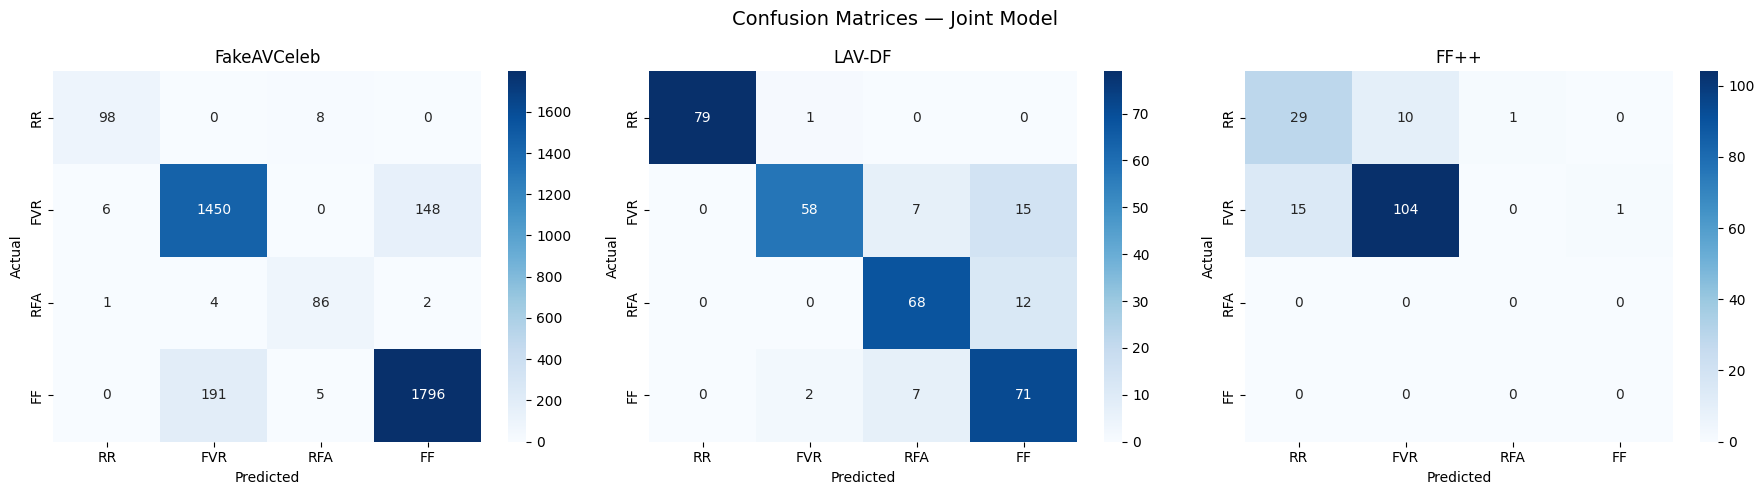

Saved confusion matrices.


In [16]:
# ── CELL 11: CONFUSION MATRICES ───────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Joint Model', fontsize=14)

for ax, (name, loader) in zip(axes, test_loaders.items()):
    _, y_true, y_pred = evaluate(loader, name)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(4)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['RR','FVR','RFA','FF'],
                yticklabels=['RR','FVR','RFA','FF'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'joint_confusion_matrices.png'), dpi=150)
plt.show()
print('Saved confusion matrices.')

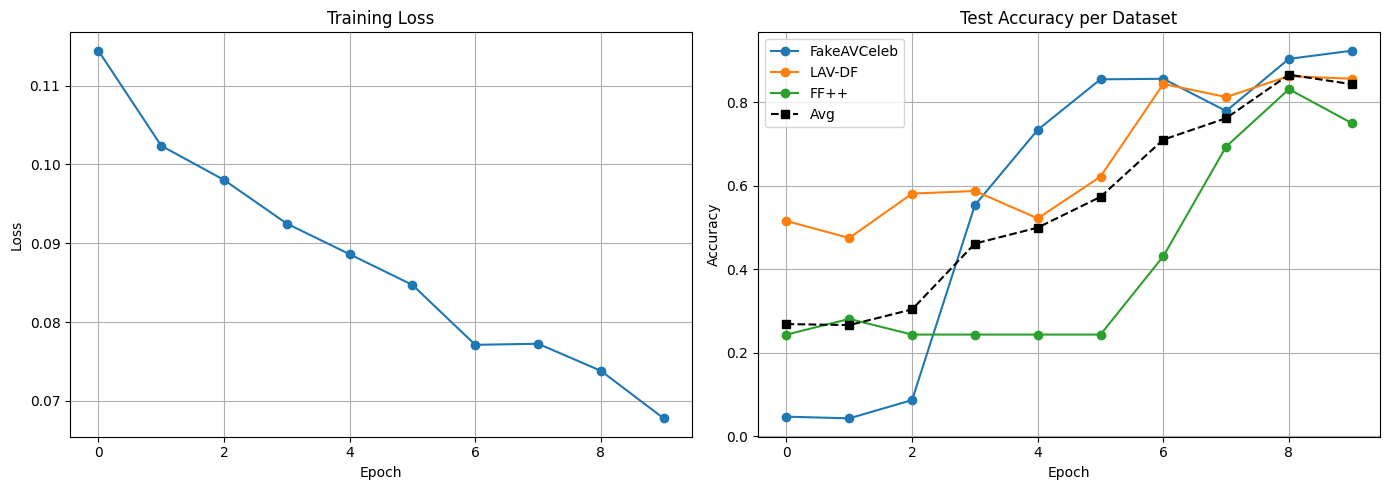

Saved training history.


In [17]:
# ── CELL 12: TRAINING HISTORY PLOT ────────────────────────────────────────

epochs = [h['epoch'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, [h['loss'] for h in history], marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

for name in ['FakeAVCeleb', 'LAV-DF', 'FF++']:
    ax2.plot(epochs, [h[name] for h in history], marker='o', label=name)
ax2.plot(epochs, [h['avg_acc'] for h in history], marker='s', linestyle='--', label='Avg', color='black')
ax2.set_title('Test Accuracy per Dataset')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'joint_training_history.png'), dpi=150)
plt.show()
print('Saved training history.')

In [18]:
# ── CELL 13: SAVE FINAL MODEL ─────────────────────────────────────────────
torch.save(model.state_dict(), MODEL_PATH)
print('Final model saved to:', MODEL_PATH)
print('Best checkpoint saved to:', CHECKPOINT_PATH)

Final model saved to: /content/drive/MyDrive/Deepfake/joint_model.pth
Best checkpoint saved to: /content/drive/MyDrive/Deepfake/joint_model_checkpoint.pth
